# Sincronização W&B e Análise de Resultados — AlexNet QAT

Notebook de análise: sincroniza os logs offline do Weights & Biases, carrega a tabela final de comparação e os históricos de treino (FP32 e QAT), e gera os gráficos de curvas de treino e Accuracy vs Model Size.

## 1. Sincronizar logs locais do W&B

In [1]:
import wandb
wandb.login()
# Sincroniza os metadados contidos na pasta local ./wandb para o servidor do W&B.
# Como o notebook principal rodou com "offline=True", esse passo é obrigatório.

print("Sincronizando logs locais com o servidor do Weights & Biases...")
!wandb sync --sync-all

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/rafael/.netrc.
wandb: Currently logged in as: rafesilvadesouza (rafesilvadesouza-ufrgs) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Sincronizando logs locais com o servidor do Weights & Biases...
wandb: ERROR Nothing to sync.


## 2. Configuração

In [2]:
import os
import json
import wandb
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import IFrame

# Caso ainda não tenha feito a autenticação na sua máquina atual,
# descomente a linha abaixo para inserir o seu token de API:
# !wandb login

WANDB_USERNAME = "rafesilvadesouza-ufrgs"
PROJECT_NAME = "tiny-imagenet"

# IMPORTANTE: precisa ser EXATAMENTE o mesmo save_dir usado no notebook de treino
from pathlib import Path
project_root = Path.cwd().parent
SAVE_DIR = str(project_root / "results" / "alexnet_qat_phase2")

## 3. Tabela final de comparação

In [3]:
csv_path = os.path.join(SAVE_DIR, "final_comparison.csv")

if os.path.exists(csv_path):
    print("Tabela Final de Comparações Encontrada localmente:")
    df_results = pd.read_csv(csv_path)
    display(df_results)
else:
    print(f"Aviso: O arquivo {csv_path} ainda não foi gerado pelo notebook de treino.")

Tabela Final de Comparações Encontrada localmente:


,model,precision,top1_%,top5_%,loss,params_M,size_MB
0,alexnet_small_kernel,FP32,42.916036,68.619573,2.496792,1.602376,18.353193
1,alexnet_mixed,FP32,42.385602,67.770153,2.517252,1.750024,20.042482
2,alexnet_stacked,FP32,41.394109,67.522848,2.521390,60.483976,692.254486
3,alexnet_3x3,FP32,36.667016,61.221510,2.923697,57.605128,659.257868
4,alexnet_2x2,FP32,36.244944,61.275673,2.863729,1.052744,12.062647
5,alexnet_tv,FP32,31.498277,56.888252,3.053009,57.823240,661.753958
6,alexnet_mixed_INT8,INT8,40.860435,66.453749,2.600502,1.750024,1.705048
7,alexnet_stacked_INT8,INT8,40.329379,66.269040,2.570608,60.483976,57.941553
8,alexnet_3x3_INT8,INT8,36.402413,60.717112,2.946081,57.605128,55.124596
9,alexnet_2x2_INT8,INT8,35.542390,60.995960,2.870966,1.052744,1.039989


## 4. Painel interativo do W&B (embed)

In [4]:
# Renderiza o workspace completo do W&B direto na saída da célula do Jupyter.
# Permite sobrepor e comparar as curvas (loss/accuracy) das execuções simultaneamente.
url_workspace = f"https://wandb.ai/{WANDB_USERNAME}/{PROJECT_NAME}?workspace=user-{WANDB_USERNAME}"
print(f"Abra o painel interativo no navegador: {url_workspace}")

Abra o painel interativo no navegador: https://wandb.ai/rafesilvadesouza-ufrgs/tiny-imagenet?workspace=user-rafesilvadesouza-ufrgs


## 5. Carregar resumo do experimento

In [5]:
summary_path = os.path.join(SAVE_DIR, "experiment_summary.json")
summary_data = None

if os.path.exists(summary_path):
    with open(summary_path, "r") as f:
        summary_data = json.load(f)
    print("Dados locais carregados com sucesso!")
else:
    print(f"Aviso: {summary_path} não encontrado. Rode o notebook de treino primeiro.")

# Model keys must match MODEL_REGISTRY names from the training notebook.
FP32_MODELS = [
    ("alexnet_tv", "AlexNet Pretrained"),
    ("alexnet_3x3", "AlexNet 3x3"),
    ("alexnet_2x2", "AlexNet 2x2"),
    ("alexnet_stacked", "AlexNet Stacked"),
    ("alexnet_mixed", "AlexNet Mixed"),
    ("alexnet_small_kernel", "AlexNet Small Kernel"),
]

QAT_MODELS = [
    ("alexnet_tv", "QAT AlexNet"),
    ("alexnet_3x3", "QAT AlexNet 3x3"),
    ("alexnet_2x2", "QAT AlexNet 2x2"),
    ("alexnet_stacked", "QAT AlexNet Stacked"),
    ("alexnet_mixed", "QAT AlexNet Mixed"),
    ("alexnet_small_kernel", "QAT AlexNet Small"),
]

Dados locais carregados com sucesso!


## 6. Função auxiliar de plotagem

In [6]:
def plot_training_curves(results_dict, model_list, title_prefix):
    """Plot val_loss, val_acc, train_acc, val_top5 for a set of models.

    `results_dict` is summary_data["fp32_training_results"] or
    summary_data["qat_training_results"]. Missing keys/metrics are skipped
    with a printed warning instead of failing silently.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    panels = [
        (axes[0, 0], "val_loss", f"{title_prefix} - Validation Loss", "Loss"),
        (axes[0, 1], "val_acc", f"{title_prefix} - Validation Accuracy", "Accuracy (%)"),
        (axes[1, 0], "train_acc", f"{title_prefix} - Training Accuracy", "Accuracy (%)"),
        (axes[1, 1], "val_top5", f"{title_prefix} - Validation Top-5 Accuracy", "Accuracy (%)"),
    ]

    for ax, metric_key, plot_title, ylabel in panels:
        for key, label in model_list:
            result = results_dict.get(key)
            if not result:
                print(f"  [skip] '{key}' not found in results (expected for '{label}')")
                continue

            history = result.get("history", {})
            if metric_key not in history:
                print(f"  [skip] '{metric_key}' missing from history for '{key}'")
                continue

            epochs = range(1, len(history[metric_key]) + 1)
            ax.plot(epochs, history[metric_key], marker="o", label=label)

        ax.set_title(plot_title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

## 7. Curvas de treino — FP32

Plotando curvas FP32...


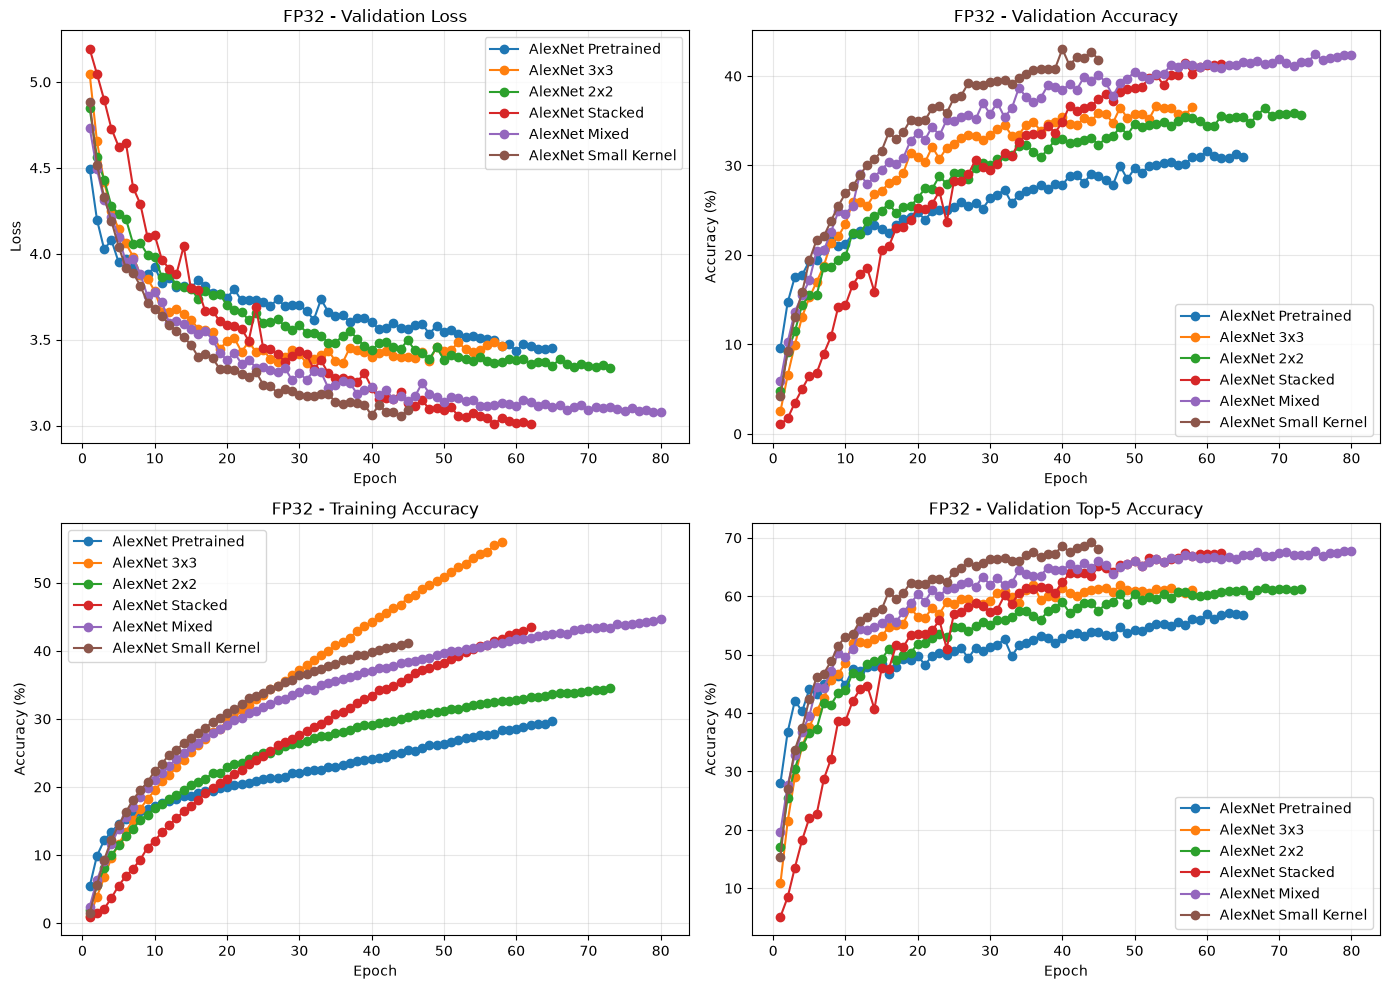

In [7]:
if summary_data is not None:
    print("Plotando curvas FP32...")
    plot_training_curves(
        summary_data.get("fp32_training_results", {}),
        FP32_MODELS,
        title_prefix="FP32",
    )
else:
    print("summary_data não carregado — pulando gráficos FP32.")

## 8. Curvas de treino — QAT / INT8

Plotando curvas QAT...


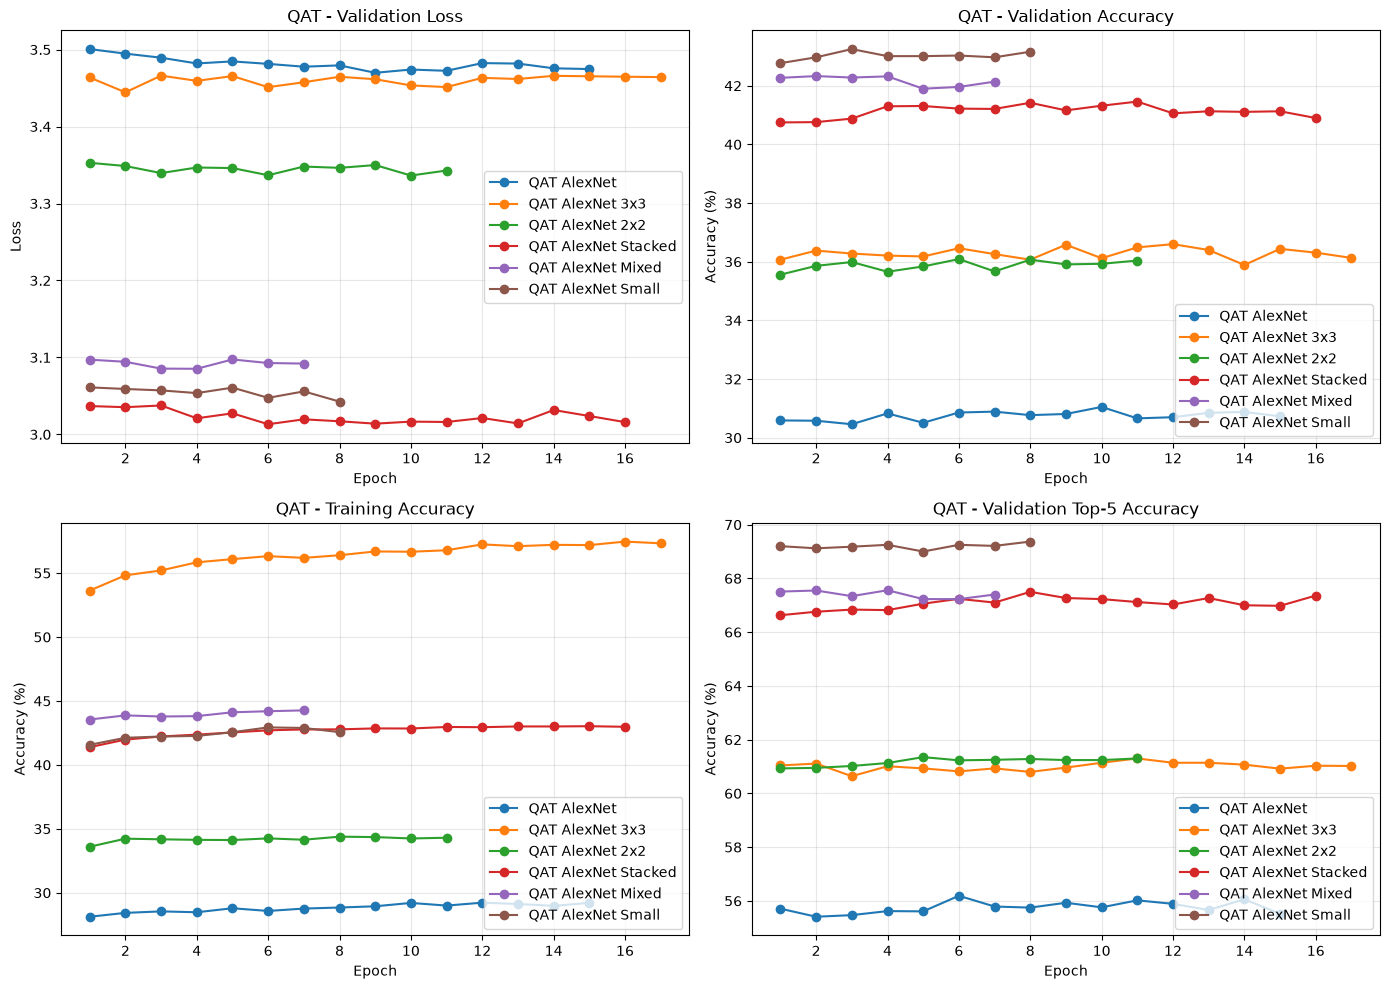

In [8]:
if summary_data is not None:
    print("Plotando curvas QAT...")
    plot_training_curves(
        summary_data.get("qat_training_results", {}),
        QAT_MODELS,
        title_prefix="QAT",
    )
else:
    print("summary_data não carregado — pulando gráficos QAT.")

## 9. Accuracy vs Tamanho do Modelo (FP32 vs INT8)

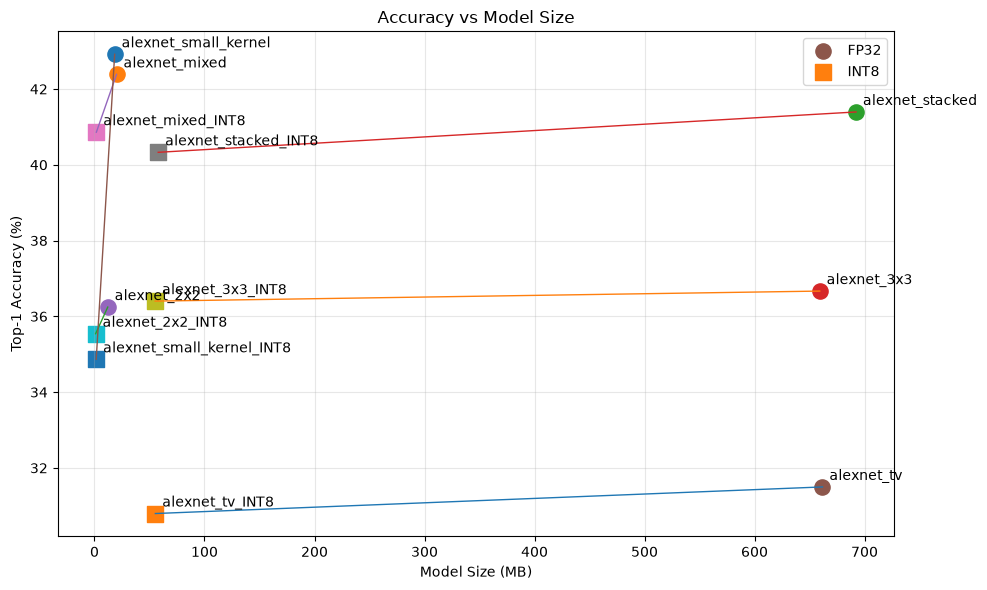

In [9]:
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    plt.figure(figsize=(10, 6))

    markers = {
        "FP32": "o",
        "INT8": "s",
    }

    pairs = [
        ("alexnet_tv", "alexnet_tv_INT8"),
        ("alexnet_3x3", "alexnet_3x3_INT8"),
        ("alexnet_2x2", "alexnet_2x2_INT8"),
        ("alexnet_stacked", "alexnet_stacked_INT8"),
        ("alexnet_mixed", "alexnet_mixed_INT8"),
        ("alexnet_small_kernel", "alexnet_small_kernel_INT8"),
    ]

    for fp32_name, int8_name in pairs:
        fp32_rows = df[df["model"] == fp32_name]
        int8_rows = df[df["model"] == int8_name]

        if fp32_rows.empty or int8_rows.empty:
            print(f"  [skip] pair ({fp32_name}, {int8_name}) not found in final_comparison.csv")
            continue

        fp32 = fp32_rows.iloc[0]
        int8 = int8_rows.iloc[0]

        plt.plot(
            [fp32["size_MB"], int8["size_MB"]],
            [fp32["top1_%"], int8["top1_%"]],
            linewidth=1,
        )

    for _, row in df.iterrows():
        plt.scatter(
            row["size_MB"],
            row["top1_%"],
            marker=markers.get(row["precision"], "x"),
            s=120,
            label=row["precision"],
        )

        plt.annotate(
            row["model"],
            (row["size_MB"], row["top1_%"]),
            xytext=(5, 5),
            textcoords="offset points",
        )

    # legenda sem duplicatas
    handles, labels = plt.gca().get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    plt.legend(unique.values(), unique.keys())

    plt.xlabel("Model Size (MB)")
    plt.ylabel("Top-1 Accuracy (%)")
    plt.title("Accuracy vs Model Size")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print(f"Aviso: {csv_path} não encontrado — pulando gráfico de Accuracy vs Size.")